### Importación de datos



In [261]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [199]:
import matplotlib.pyplot as plt
import matplotlib as mpl

#1. Análisis de facturación



In [200]:
# Variable global
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda1', 'Tienda2', 'Tienda3', 'Tienda4']

In [201]:
suma_precios_tienda = [tienda["Precio"].sum() for tienda in tiendas]

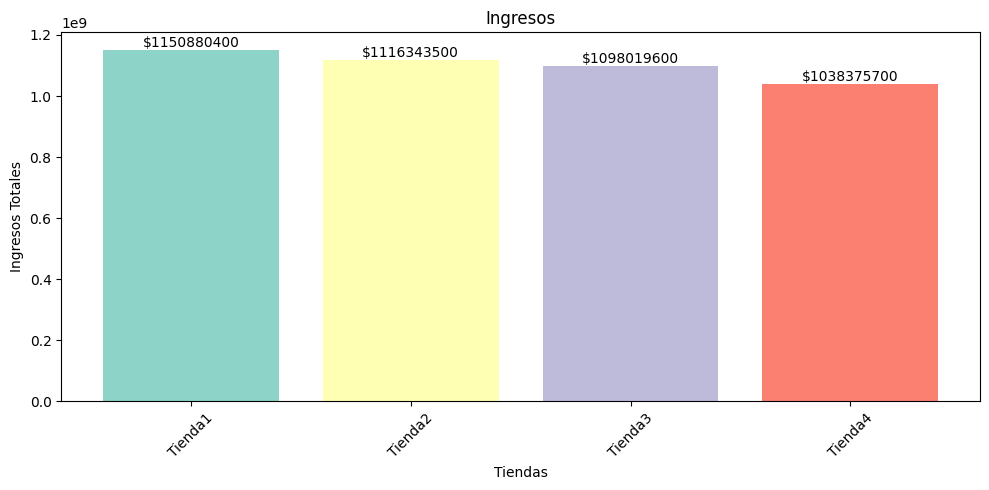

In [216]:
def ingresosTiendas():
    plt.figure(figsize=(10, 5))
    colores = mpl.colormaps['Set3']
    colors = [colores(i) for i in range(len(nombres))]
    bars = plt.bar(nombres, suma_precios_tienda, color=colors)

    plt.xlabel("Tiendas")
    plt.ylabel("Ingresos Totales")
    plt.title("Ingresos")
    plt.xticks(rotation=45)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1000,
            f'${int(height)}',
            ha='center', va='bottom', fontsize=10
        )

    plt.tight_layout()
    plt.show()

ingresosTiendas()

# 2. Ventas por categoría

In [203]:
def categorias_tiendas(tienda, nombre):
  categorias = {}
  for i in range(len(tienda)):
      categoria = tienda.loc[i, "Categoría del Producto"]

      if categoria in categorias:
          categorias[categoria] += 1
      else:
          categorias[categoria] = 1
  print(categorias)
  return graficos_tiendas(categorias, nombre)

In [221]:
def graficos_tiendas(categorias,nombre):
  plt.figure(figsize=(10, 5))
  colores = mpl.colormaps['viridis']
  colors = [colores(i / len(nombres)) for i in range(len(nombres))]
  plt.bar(categorias.keys(), categorias.values(), color=colors)
  plt.xlabel("Categoría del Producto")
  plt.ylabel("Suma de Ventas")
  plt.title(f"Ventas por Categoría de {nombre}")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

{'Electrónicos': 448, 'Muebles': 465, 'Juguetes': 324, 'Electrodomésticos': 312, 'Artículos para el hogar': 171, 'Deportes y diversión': 284, 'Libros': 173, 'Instrumentos musicales': 182}


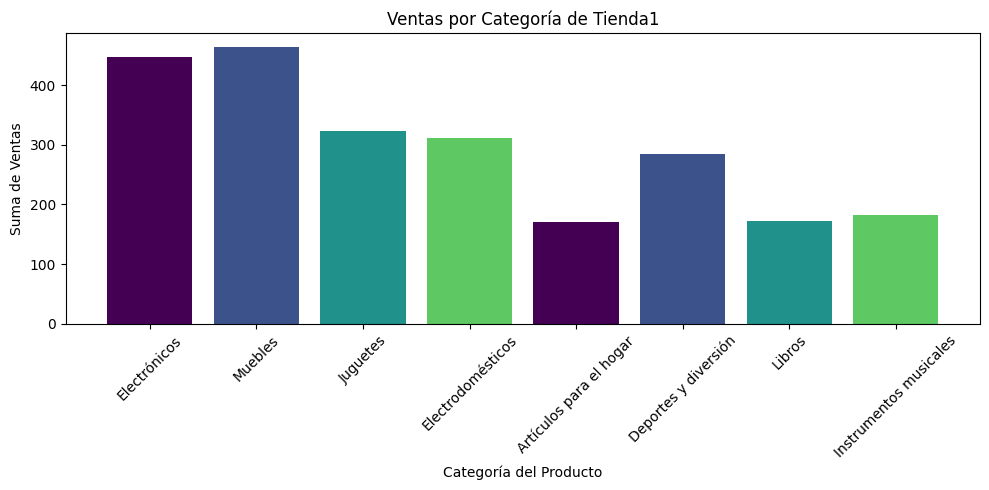

{'Muebles': 442, 'Instrumentos musicales': 224, 'Deportes y diversión': 275, 'Electrónicos': 422, 'Artículos para el hogar': 181, 'Juguetes': 313, 'Electrodomésticos': 305, 'Libros': 197}


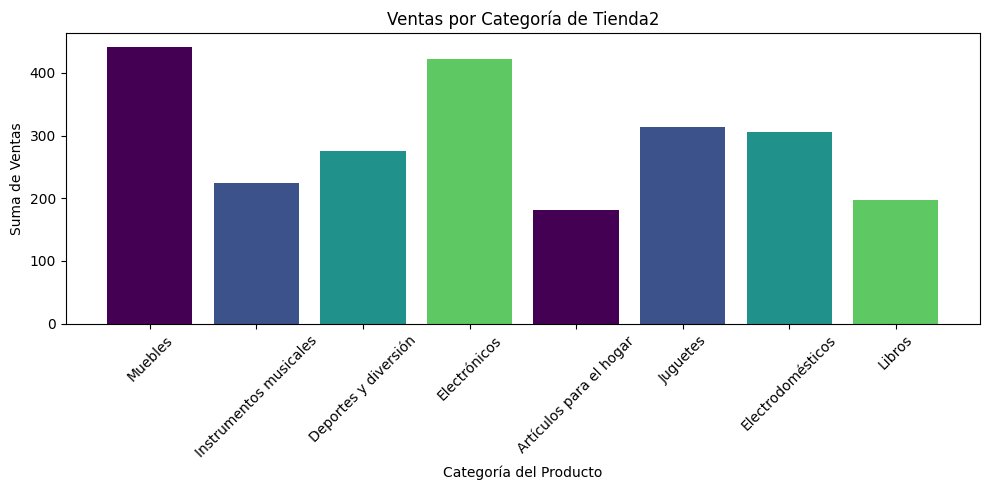

{'Electrodomésticos': 278, 'Muebles': 499, 'Instrumentos musicales': 177, 'Deportes y diversión': 277, 'Electrónicos': 451, 'Juguetes': 315, 'Artículos para el hogar': 177, 'Libros': 185}


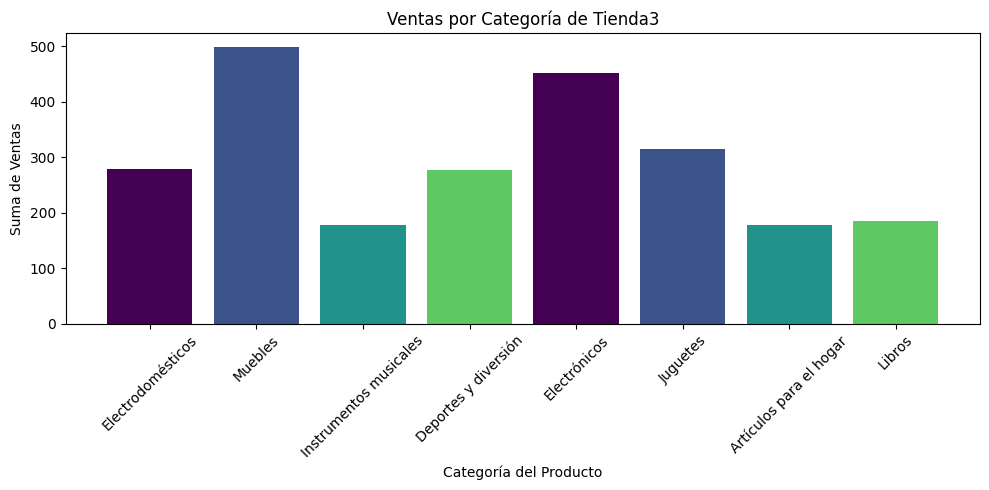

{'Electrodomésticos': 254, 'Muebles': 480, 'Deportes y diversión': 277, 'Libros': 187, 'Electrónicos': 451, 'Instrumentos musicales': 170, 'Juguetes': 338, 'Artículos para el hogar': 201}


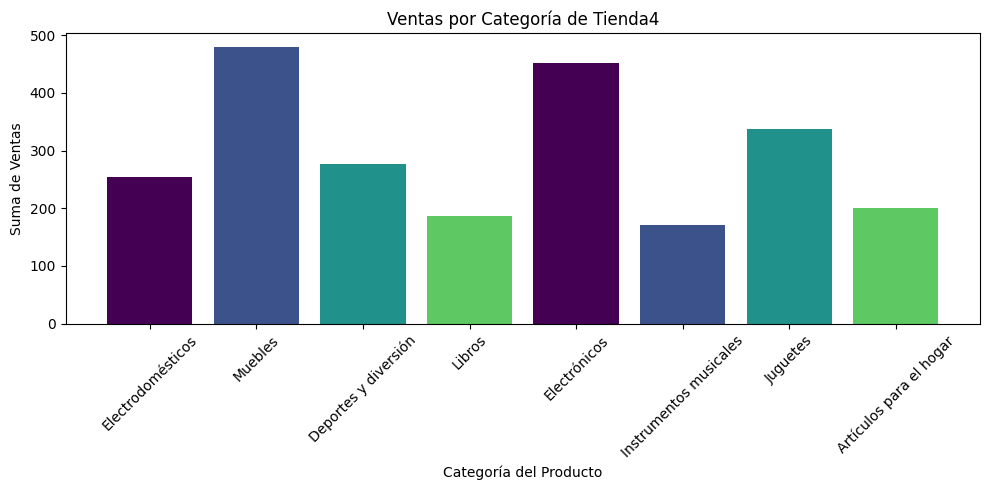

In [222]:
lista_categorias = [categorias_tiendas(tienda, i) for tienda, i in zip(tiendas, nombres)]


# 3. Calificación promedio de la tienda


In [206]:
def valoracion_promedio(tienda):
  promedio = round(tienda['Calificación'].sum()/len(tienda),2)
  return promedio

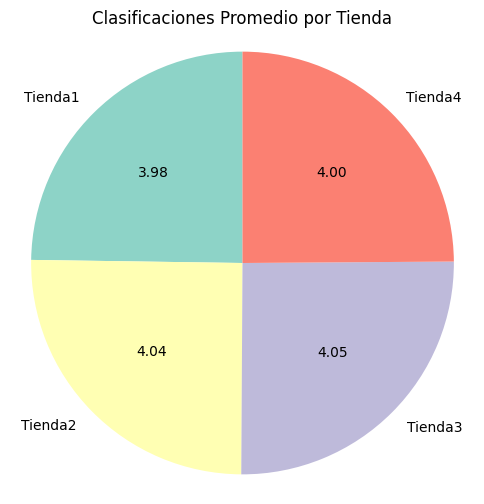

In [207]:
valores = [valoracion_promedio(tienda) for tienda in tiendas]

def mostrar_valor(pct, valores):
    total = sum(valores)
    valor = pct * total / 100.0
    return f'{valor:.2f}'

plt.figure(figsize=(6, 6))
colores = mpl.colormaps['Set3']
colors = [colores(i) for i in range(len(nombres))]
plt.pie(valores, labels=nombres, autopct=lambda pct: mostrar_valor(pct, valores),
        startangle=90, colors=colors)
plt.title('Clasificaciones Promedio por Tienda')
plt.axis('equal')
plt.show()

# 4. Productos más y menos vendidos

In [208]:
def mayor_y_menor(tienda):
  productos = {}
  for i in range(len(tienda)):
    producto = tienda.loc[i, "Producto"]

    if producto in productos:
      productos[producto] += 1
    else:
      productos[producto] = 1
  productos_ordenados = dict(sorted(productos.items(), key=lambda item: item[1], reverse=True))
  mas_vendido = next(iter(productos_ordenados.items()))
  menos_vendido = next(reversed(productos_ordenados.items()))
  return mas_vendido, menos_vendido


In [238]:
def mostrar_mas_y_menos_vendido(tienda,nombre):
    mas_vendido, menos_vendido = mayor_y_menor(tienda)

    productos = [mas_vendido[0], menos_vendido[0]]
    cantidades = [mas_vendido[1], menos_vendido[1]]

    colores = ['#4CAF50', '#F44336']

    plt.figure(figsize=(8, 4))
    bars = plt.barh(productos, cantidades, color=colores)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{int(width)} ventas', va='center')

    plt.xlim(0, max(cantidades) + 10)
    plt.xlabel("Cantidad de Ventas")
    plt.title(f"Producto Menos Vendido vs. Más Vendido en {nombre}")
    plt.tight_layout()
    plt.show()


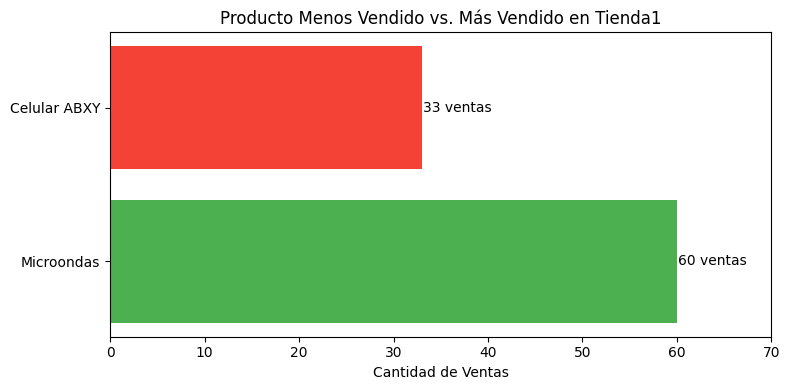

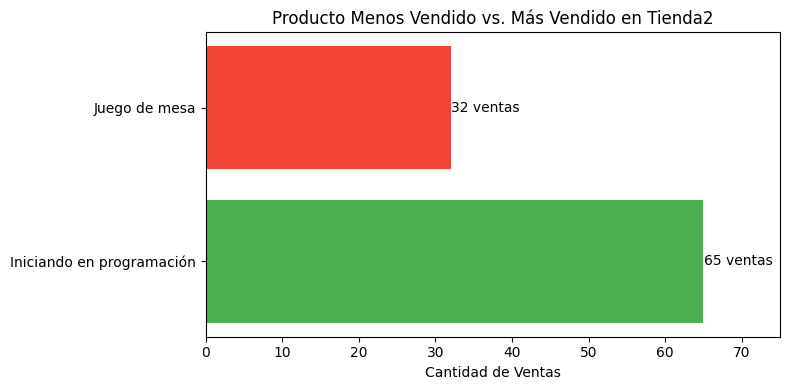

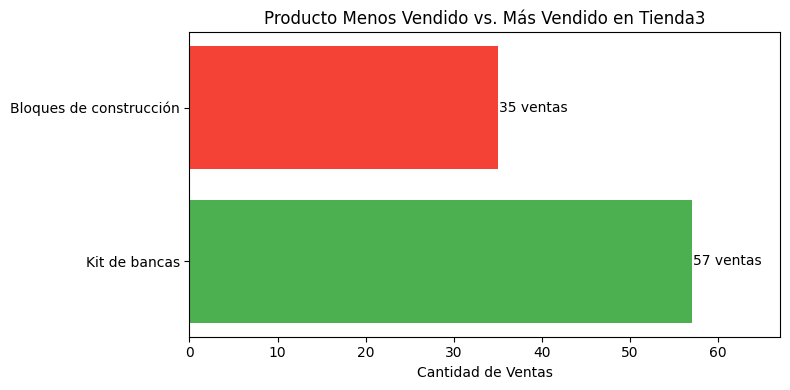

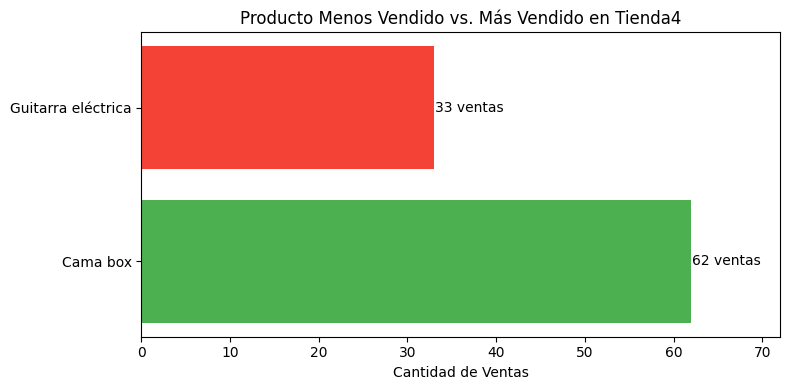

In [239]:
for tienda, nombre in zip(tiendas,nombres):
  mostrar_mas_y_menos_vendido(tienda,nombre)


# 5. Envío promedio por tienda

In [211]:
def promedio_envio(tienda):
  promedio = round(tienda['Costo de envío'].sum()/len(tienda))
  return float(promedio)

lista_promedios = [promedio_envio(tienda) for tienda in tiendas]

In [254]:
def graficos_promedio_envio(promedios):
    plt.figure(figsize=(8, 5))
    colores = mpl.colormaps['Set3']
    colors = [colores(i) for i in range(len(promedios))]

    bars = plt.bar(nombres, promedios, color=colors)

    plt.xlabel("Tiendas")
    plt.ylabel("Costo Promedio de Envío")
    plt.title("Promedios de Envíos por Tienda")
    plt.xticks(rotation=45)

    max_val = max(promedios)
    plt.ylim(top=max_val + 2000)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 500,
            f'${int(height)}',
            ha='center', va='bottom', fontsize=10
        )

    plt.tight_layout()
    plt.show()


In [255]:
def graficos_promedio_envio_pie(promedios):
    plt.figure(figsize=(3, 3))
    colores = mpl.colormaps['Set3']
    colors = [colores(i) for i in range(len(promedios))]

    # Crear gráfico de pastel solo con porcentajes
    plt.pie(promedios, labels=nombres, autopct='%1.1f%%', startangle=90, colors=colors)

    plt.title("Promedios de Envíos por Tienda")
    plt.axis('equal')  # Para que el gráfico sea circular
    plt.tight_layout()
    plt.show()

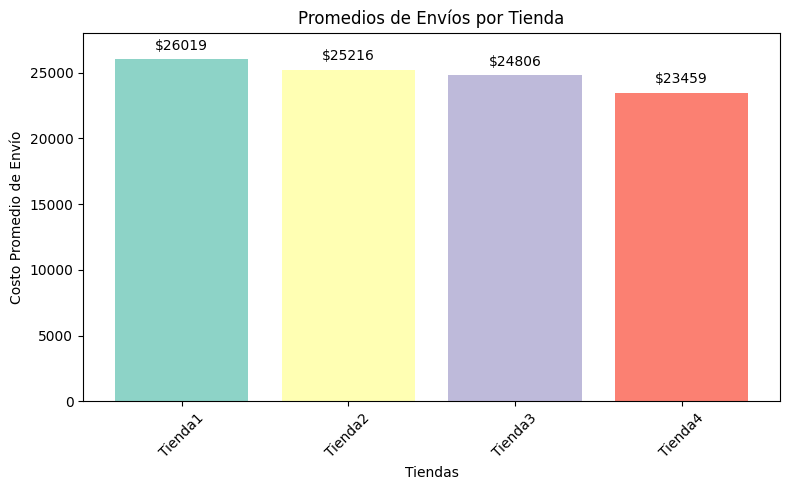

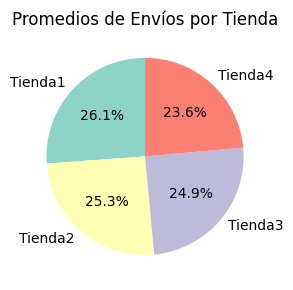

In [256]:
graficos_promedio_envio(lista_promedios)
graficos_promedio_envio_pie(lista_promedios)

In [213]:
#488074 #473428 #465657 #440,362

In [ ]:
#462055 #448,212 #440856 #416903